In [1]:
# -------------------------------------------------------------
# Common pre‑amble – read config & export core variables
# -------------------------------------------------------------

from pathlib import Path
import os, sys

# infer repo root from the location of this file
repo_root = os.path.abspath('..')
sys.path.insert(0, str(repo_root))  # allow `import src.*`
from config.notebook_setup import *

Repository Root: /home/marcmaceira/projects/reuters-rag-classifier
Configuration: {'run_name': 'experiment_with_10_classes', 'seed': 42, 'n_classes': 10, 'cutoff_year': 1996, 'data_dir': '${run_name}/data', 'artifacts_dir': '${run_name}/artifacts', 'embeddings_dir': '${run_name}/embeddings', 'models_dir': '${run_name}/models', 'results_dir': '${run_name}/results', 'embedding_backend': 'sbert', 'sbert_model_name': 'sentence-transformers/all-MiniLM-L12-v2', 'openai_model_name': 'text-embedding-3-small', 'classifier': 'linear_svm', 'rag_top_k': 5, 'use_llm_refine': False, 'batch_size': 32, 'max_epochs': 10, 'learning_rate': '1e-3', 'weight_decay': '1e-4', 'early_stopping': 3, 'test_split': 0.2, 'metrics': ['accuracy', 'macro_f1', 'auc_ovr']}
DATA_DIR: /home/marcmaceira/projects/reuters-rag-classifier/${run_name}/data
ARTIFACTS_DIR: /home/marcmaceira/projects/reuters-rag-classifier/${run_name}/artifacts
EMB_DIR: /home/marcmaceira/projects/reuters-rag-classifier/${run_name}/embeddings
MODEL

# Reuters News Topic Classification - Data Loading

This notebook handles the initial data loading and preprocessing for the Reuters news topic classification task. We'll be using the Reuters-21578 corpus, a classic dataset of Reuters newswire articles labeled with economic topics.

## Dataset Overview

The Reuters-21578 corpus is a collection of 10,788 Reuters newswire articles that have been labeled with economic topics. Key features:

* Open license - freely redistributable for research/commercial use
* Rich, domain-specific text - financial and commodities news
* Benchmark pedigree - allows comparison against decades of literature

## Setup and Imports

In [2]:
import logging
import warnings
from src.datasets.dataset import load_data, load_data_temporal

warnings.filterwarnings('ignore')
logging.basicConfig(level=logging.INFO, format='%(levelname)s | %(message)s')

## Load Dataset

We'll load the top 10 topics for clarity in our classification task.

In [3]:
# Load dataset with top N_CLASSES topics
X_train, y_train, X_test, y_test, label_names = load_data(N_CLASSES)
print(f'Train docs: {len(X_train):,},  Test docs: {len(X_test):,}')
print('Labels:', label_names)

Train docs: 6,337,  Test docs: 2,477
Labels: ['earn', 'acq', 'crude', 'interest', 'money-fx', 'trade', 'grain', 'corn', 'dlr', 'money-supply']


## Temporal Split

We can also load the data using a temporal split, where articles before 1996 are used for training and those after for testing. This better reflects real-world deployment scenarios.

In [4]:
# Load using temporal split
X_train, y_train, X_test, y_test, label_names = load_data_temporal(
    cutoff_year=CUTOFF_YEAR,
    n_classes=N_CLASSES
)
print(f"Train docs: {len(X_train):,},  Test docs: {len(X_test):,}")

Train docs: 6,337,  Test docs: 2,477


## Data Exploration

Let's examine the distribution of classes and article lengths to understand our dataset better.

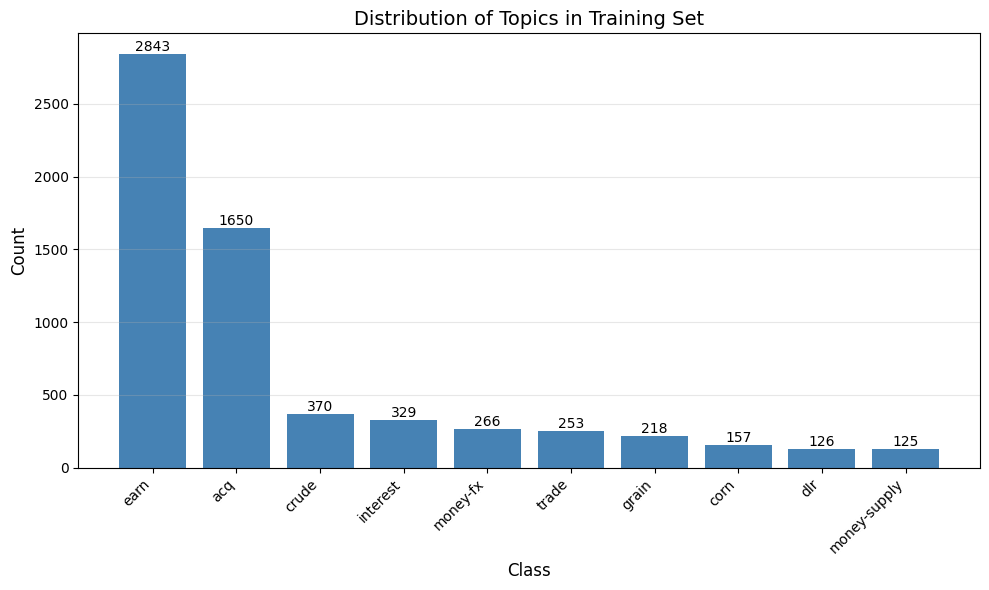

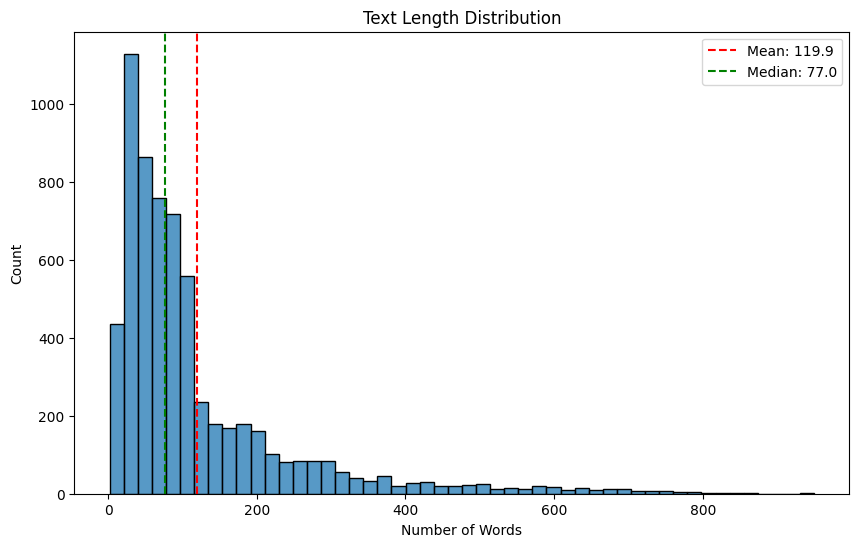

Mean length: 119.9 tokens, median: 77.0


In [5]:
from src.exploration import class_frequency, length_distribution
import pandas as pd


# Imbalance plot
class_frequency(y_train, top_n=20)

# Article length distribution
stats = length_distribution(X_train)
print(f"Mean length: {stats['stats']['mean']:.1f} tokens, median: {stats['stats']['median']}")

## Next Steps

The data has been loaded and preprocessed. In the next notebook, we'll perform more detailed exploratory data analysis to better understand the characteristics of our dataset.